# AOI TensorRT Benchmark — YOLOv8s-seg metal_nut
#
Optimization of an Ultralytics YOLOv8s-seg model (mAP@50 0.75 on MVTec AD metal_nut)
through the NVIDIA inference stack: **PyTorch → ONNX → TensorRT (FP32 / FP16 / INT8)**.
#
## Hardware
- NVIDIA Tesla T4 (16 GB, compute capability 7.5, Turing)
- CUDA 12.x, TensorRT 10.x
#
## Source
- ONNX (opset 17, dynamic batch): `yolov8s_seg_metal_nut.onnx` (45 MB)
#
## Result Preview
| Precision | Latency mean (ms) | Throughput (qps) | Speedup |
|-----------|-------------------|------------------|---------|
| FP32      | 10.91             | 91.6             | 1.00×   |
| FP16      | 3.49              | 286.5            | 3.13×   |
| INT8      | 2.09              | 478.1            | **5.22×** |

---
## 1. Environment & Hardware

In [39]:
!nvidia-smi --query-gpu=name,driver_version,memory.total --format=csv
print()
import tensorrt as trt
print(f"TensorRT: {trt.__version__}")
print(f"FP16 fast: {trt.Builder(trt.Logger()).platform_has_fast_fp16}")
print(f"INT8 fast: {trt.Builder(trt.Logger()).platform_has_fast_int8}")

name, driver_version, memory.total [MiB]
Tesla T4, 580.105.08, 15360 MiB
Tesla T4, 580.105.08, 15360 MiB

TensorRT: 10.16.1.11
FP16 fast: True
INT8 fast: True
[05/07/2026-18:39:44] [TRT] [W] WARNING The logger passed into createInferBuilder differs from one already registered for an existing builder, runtime, or refitter. So the current new logger is ignored, and TensorRT will use the existing one which is returned by nvinfer1::getLogger() instead.
[05/07/2026-18:39:44] [TRT] [W] WARNING The logger passed into createInferBuilder differs from one already registered for an existing builder, runtime, or refitter. So the current new logger is ignored, and TensorRT will use the existing one which is returned by nvinfer1::getLogger() instead.


---
## 2. ONNX Source Discovery
#
Auto-locate the uploaded ONNX file (Kaggle dataset path varies by username slug).

In [40]:
import glob, os
matches = glob.glob("/kaggle/input/**/yolov8s_seg_metal_nut.onnx", recursive=True)
assert matches, "ONNX not found under /kaggle/input/"
ONNX_PATH = matches[0]
print(f"ONNX_PATH = {ONNX_PATH}")
print(f"size = {os.path.getsize(ONNX_PATH) / 1e6:.1f} MB")

ONNX_PATH = /kaggle/input/datasets/yhtsengkaggle/aoi-onnx-models/yolov8s_seg_metal_nut.onnx
size = 47.7 MB


---
## 3. Output Path Constants

In [41]:
ENGINE_DIR = "/kaggle/working/engines"
LOG_DIR = "/kaggle/working/logs"
os.makedirs(ENGINE_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

ENGINE_FP32 = f"{ENGINE_DIR}/metal_nut_fp32.engine"
ENGINE_FP16 = f"{ENGINE_DIR}/metal_nut_fp16.engine"
ENGINE_INT8 = f"{ENGINE_DIR}/metal_nut_int8.engine"
CALIB_CACHE = f"{ENGINE_DIR}/metal_nut_int8.cache"

print(f"engines  → {ENGINE_DIR}")
print(f"logs     → {LOG_DIR}")

engines  → /kaggle/working/engines
logs     → /kaggle/working/logs


---
## 4. Reusable Build Helper
#
Single function that parses ONNX, applies precision flags, and serializes engine.
Returns build time in seconds.

In [42]:
import time


def build_engine(onnx_path, out_path, precision="fp32",
                 calibrator=None, workspace_gb=4):
    """
    precision in {"fp32", "fp16", "int8"}.
    Returns build time (seconds).
    """
    logger = trt.Logger(trt.Logger.WARNING)
    builder = trt.Builder(logger)
    network = builder.create_network(
        1 << int(trt.NetworkDefinitionCreationFlag.EXPLICIT_BATCH)
    )
    parser = trt.OnnxParser(network, logger)

    with open(onnx_path, 'rb') as f:
        if not parser.parse(f.read()):
            for e in range(parser.num_errors):
                print(parser.get_error(e))
            raise RuntimeError("ONNX parse failed")

    config = builder.create_builder_config()
    config.set_memory_pool_limit(trt.MemoryPoolType.WORKSPACE, workspace_gb << 30)

    profile = builder.create_optimization_profile()
    profile.set_shape("images", (1, 3, 640, 640), (1, 3, 640, 640), (8, 3, 640, 640))
    config.add_optimization_profile(profile)

    if precision == "fp16":
        config.set_flag(trt.BuilderFlag.FP16)
    elif precision == "int8":
        assert calibrator is not None, "INT8 requires a calibrator"
        config.set_flag(trt.BuilderFlag.INT8)
        config.set_flag(trt.BuilderFlag.FP16)  # FP16 fallback for non-INT8 layers

        # Dedicated calibration profile (fixed shape)
        calib_profile = builder.create_optimization_profile()
        calib_profile.set_shape(
            "images", (1, 3, 640, 640), (1, 3, 640, 640), (1, 3, 640, 640)
        )
        config.set_calibration_profile(calib_profile)
        config.int8_calibrator = calibrator

    print(f"Building {precision.upper()} engine...")
    t0 = time.time()
    engine_bytes = builder.build_serialized_network(network, config)
    elapsed = time.time() - t0

    if engine_bytes is None:
        raise RuntimeError(f"{precision.upper()} engine build returned None")

    with open(out_path, 'wb') as f:
        f.write(engine_bytes)

    size_mb = os.path.getsize(out_path) / 1e6
    print(f"Saved: {out_path} ({size_mb:.2f} MB)")
    print(f"{precision.upper()} build time: {elapsed:.1f} s")
    return elapsed

---
## 5. Reusable Benchmark Helper
#
Engine load + warmup + per-iteration GPU event timing.
Returns dict of latency/throughput stats.

In [43]:
import numpy as np
import pycuda.driver as cuda
import pycuda.autoinit  # auto-init CUDA context (must import before benchmarks)


def load_engine(path):
    with open(path, 'rb') as f:
        runtime = trt.Runtime(trt.Logger(trt.Logger.WARNING))
        return runtime.deserialize_cuda_engine(f.read())


def benchmark(engine_path, batch=1, imgsz=640, warmup=50, iters=500):
    engine = load_engine(engine_path)
    context = engine.create_execution_context()

    n_io = engine.num_io_tensors
    tensor_names = [engine.get_tensor_name(i) for i in range(n_io)]
    input_name = next(
        n for n in tensor_names
        if engine.get_tensor_mode(n) == trt.TensorIOMode.INPUT
    )
    output_names = [
        n for n in tensor_names
        if engine.get_tensor_mode(n) == trt.TensorIOMode.OUTPUT
    ]
    context.set_input_shape(input_name, (batch, 3, imgsz, imgsz))

    h_input = np.random.rand(batch, 3, imgsz, imgsz).astype(np.float32)
    d_input = cuda.mem_alloc(h_input.nbytes)
    context.set_tensor_address(input_name, int(d_input))

    d_outputs = {}
    for oname in output_names:
        oshape = tuple(context.get_tensor_shape(oname))
        h_out = np.empty(oshape, dtype=np.float32)
        d_outputs[oname] = cuda.mem_alloc(h_out.nbytes)
        context.set_tensor_address(oname, int(d_outputs[oname]))

    stream = cuda.Stream()
    cuda.memcpy_htod_async(d_input, h_input, stream)
    for _ in range(warmup):
        context.execute_async_v3(stream.handle)
    stream.synchronize()

    times_ms = []
    for _ in range(iters):
        cuda.memcpy_htod_async(d_input, h_input, stream)
        start, end = cuda.Event(), cuda.Event()
        start.record(stream)
        context.execute_async_v3(stream.handle)
        end.record(stream)
        end.synchronize()
        times_ms.append(start.time_till(end))

    times_ms = np.array(times_ms)
    return {
        'mean_ms': float(times_ms.mean()),
        'median_ms': float(np.median(times_ms)),
        'p99_ms': float(np.percentile(times_ms, 99)),
        'min_ms': float(times_ms.min()),
        'max_ms': float(times_ms.max()),
        'throughput_qps': float(1000.0 / times_ms.mean() * batch),
    }

---
## 6. FP32 — Baseline
#
No precision flag. Workspace 4 GB, dynamic batch profile.

In [44]:
build_time_fp32 = build_engine(ONNX_PATH, ENGINE_FP32, precision="fp32")

[05/07/2026-18:39:45] [TRT] [W] WARNING The logger passed into createInferBuilder differs from one already registered for an existing builder, runtime, or refitter. So the current new logger is ignored, and TensorRT will use the existing one which is returned by nvinfer1::getLogger() instead.
Building FP32 engine...
Saved: /kaggle/working/engines/metal_nut_fp32.engine (57.92 MB)
FP32 build time: 120.4 s


In [45]:
fp32_stats = benchmark(ENGINE_FP32, batch=1)
print("FP32 benchmark:")
for k, v in fp32_stats.items():
    print(f"  {k}: {v:.3f}")

[05/07/2026-18:41:46] [TRT] [W] WARNING The logger passed into createInferRuntime differs from one already registered for an existing builder, runtime, or refitter. So the current new logger is ignored, and TensorRT will use the existing one which is returned by nvinfer1::getLogger() instead.
FP32 benchmark:
  mean_ms: 11.521
  median_ms: 11.501
  p99_ms: 11.962
  min_ms: 11.213
  max_ms: 12.080
  throughput_qps: 86.800


---
## 7. FP16
#
`BuilderFlag.FP16` enabled. Most conv layers run FP16; non-friendly ops
(softmax, layer-norm) auto-fallback to FP32.
#
Expected: 2-3× speedup with negligible mAP impact.

In [46]:
build_time_fp16 = build_engine(ONNX_PATH, ENGINE_FP16, precision="fp16")

[05/07/2026-18:41:53] [TRT] [W] WARNING The logger passed into createInferBuilder differs from one already registered for an existing builder, runtime, or refitter. So the current new logger is ignored, and TensorRT will use the existing one which is returned by nvinfer1::getLogger() instead.
Building FP16 engine...
Saved: /kaggle/working/engines/metal_nut_fp16.engine (25.48 MB)
FP16 build time: 289.5 s


In [47]:
fp16_stats = benchmark(ENGINE_FP16, batch=1)
print("FP16 benchmark:")
for k, v in fp16_stats.items():
    print(f"  {k}: {v:.3f}")

[05/07/2026-18:46:43] [TRT] [W] WARNING The logger passed into createInferRuntime differs from one already registered for an existing builder, runtime, or refitter. So the current new logger is ignored, and TensorRT will use the existing one which is returned by nvinfer1::getLogger() instead.
FP16 benchmark:
  mean_ms: 3.452
  median_ms: 3.437
  p99_ms: 3.765
  min_ms: 3.328
  max_ms: 3.979
  throughput_qps: 289.684


---
## 8. INT8 — Entropy Calibration
#
INT8 quantization requires calibration. ~335 representative MVTec metal_nut images
(220 train/good + 22 test/good + 93 test/defect across 4 defect types) are passed
through the model to compute per-layer activation histograms. TensorRT's entropy
minimization selects optimal quantization scales.
#
Implementation: `IInt8EntropyCalibrator2` subclass with image-by-image batch feed
and persistent calibration cache.
#
Preprocessing matches Ultralytics inference: BGR→RGB, resize 640×640, /255,
HWC→CHW, FP32.

### 8a. Collect calibration images

In [48]:
from pathlib import Path

CALIB_ROOT = Path("/kaggle/input/datasets/yhtsengkaggle/mvtec-metal-nut-calib")
calib_imgs = sorted(
    p for p in CALIB_ROOT.rglob("*.png") if not p.name.startswith("._")
)
assert calib_imgs, "No calibration images found"
print(f"Calibration images: {len(calib_imgs)}")
print(f"First: {calib_imgs[0]}")
print(f"Last:  {calib_imgs[-1]}")

Calibration images: 335
First: /kaggle/input/datasets/yhtsengkaggle/mvtec-metal-nut-calib/test/bent/000.png
Last:  /kaggle/input/datasets/yhtsengkaggle/mvtec-metal-nut-calib/train/good/219.png


### 8b. Calibrator class

In [49]:
import cv2


class MVTecCalibrator(trt.IInt8EntropyCalibrator2):
    """
    Entropy calibrator feeding preprocessed MVTec metal_nut images.
    Preprocessing matches Ultralytics YOLOv8 inference.
    """

    def __init__(self, image_paths, batch_size=1, imgsz=640, cache_path=CALIB_CACHE):
        super().__init__()
        self.image_paths = [p for p in image_paths if not Path(p).name.startswith("._")]
        self.batch_size = batch_size
        self.imgsz = imgsz
        self.cache_path = cache_path
        self.cursor = 0
        self.batch_nbytes = batch_size * 3 * imgsz * imgsz * 4  # FP32
        self.d_input = cuda.mem_alloc(self.batch_nbytes)

    def get_batch_size(self):
        return self.batch_size

    def get_batch(self, names):
        if self.cursor + self.batch_size > len(self.image_paths):
            return None

        host_batch = np.empty((self.batch_size, 3, self.imgsz, self.imgsz),
                              dtype=np.float32)
        for i in range(self.batch_size):
            img_path = str(self.image_paths[self.cursor + i])
            img = cv2.imread(img_path)
            if img is None:
                raise RuntimeError(f"Cannot read {img_path}")
            img = cv2.resize(img, (self.imgsz, self.imgsz))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = img.transpose(2, 0, 1).astype(np.float32) / 255.0
            host_batch[i] = img

        cuda.memcpy_htod(self.d_input, host_batch)
        self.cursor += self.batch_size
        if self.cursor % 50 < self.batch_size:
            print(f"  calibrated {self.cursor}/{len(self.image_paths)}", flush=True)
        return [int(self.d_input)]

    def read_calibration_cache(self):
        if os.path.exists(self.cache_path):
            with open(self.cache_path, "rb") as f:
                return f.read()
        return None

    def write_calibration_cache(self, cache):
        with open(self.cache_path, "wb") as f:
            f.write(cache)


print("Calibrator class ready")

Calibrator class ready


### 8c. Build INT8 engine
#
Calibration runs through all images on first build (~5-10 min). Cache written
to `metal_nut_int8.cache` for reproducible re-builds (~1 min on cache hit).

In [50]:
calibrator = MVTecCalibrator(image_paths=calib_imgs)
build_time_int8 = build_engine(
    ONNX_PATH, ENGINE_INT8, precision="int8", calibrator=calibrator,
)
print(f"Calibration cache: {CALIB_CACHE} "
      f"({os.path.getsize(CALIB_CACHE)/1e3:.1f} KB)")

[05/07/2026-18:46:47] [TRT] [W] WARNING The logger passed into createInferBuilder differs from one already registered for an existing builder, runtime, or refitter. So the current new logger is ignored, and TensorRT will use the existing one which is returned by nvinfer1::getLogger() instead.
Building INT8 engine...


/tmp/ipykernel_57/1987768503.py:42: DeprecationWarning: Use Deprecated in TensorRT 10.1. Superseded by explicit quantization. instead.
  config.set_calibration_profile(calib_profile)
/tmp/ipykernel_57/1987768503.py:43: DeprecationWarning: Use Deprecated in TensorRT 10.1. Superseded by explicit quantization. instead.
  config.int8_calibrator = calibrator


Saved: /kaggle/working/engines/metal_nut_int8.engine (15.04 MB)
INT8 build time: 480.8 s
Calibration cache: /kaggle/working/engines/metal_nut_int8.cache (14.9 KB)


In [51]:
int8_stats = benchmark(ENGINE_INT8, batch=1)
print("INT8 benchmark:")
for k, v in int8_stats.items():
    print(f"  {k}: {v:.3f}")

[05/07/2026-18:54:47] [TRT] [W] WARNING The logger passed into createInferRuntime differs from one already registered for an existing builder, runtime, or refitter. So the current new logger is ignored, and TensorRT will use the existing one which is returned by nvinfer1::getLogger() instead.
INT8 benchmark:
  mean_ms: 2.093
  median_ms: 2.034
  p99_ms: 3.093
  min_ms: 1.973
  max_ms: 3.125
  throughput_qps: 477.751


---
## 9. ONNX Sanity Check
#
Confirm exported ONNX produces well-formed output (CPU EP, deterministic).

In [52]:
import onnxruntime as ort

sess = ort.InferenceSession(ONNX_PATH, providers=['CPUExecutionProvider'])
input_name_onnx = sess.get_inputs()[0].name

np.random.seed(42)
x = np.random.rand(1, 3, 640, 640).astype(np.float32)
onnx_outputs = sess.run(None, {input_name_onnx: x})
print("ONNX outputs:")
for i, o in enumerate(onnx_outputs):
    print(f"  output[{i}].shape={o.shape}  mean={o.mean():.6f}  std={o.std():.6f}")

ONNX outputs:
  output[0].shape=(1, 37, 8400)  mean=22.194586  std=86.580544
  output[1].shape=(1, 32, 160, 160)  mean=0.143044  std=0.653913


---
## 10. Per-Precision Functional Validation
#
Same fixed-seed input through all three TRT engines. Confirms determinism and
bounds the numerical drift across precision levels.
#
Expected drift vs FP32:
- FP16: < 0.01% (single-precision rounding)
- INT8: 1-10% (quantization error)

In [53]:
np.random.seed(42)
x_test = np.random.rand(1, 3, 640, 640).astype(np.float32)

per_precision_outputs = {}

for name, engine_path in [("FP32", ENGINE_FP32),
                          ("FP16", ENGINE_FP16),
                          ("INT8", ENGINE_INT8)]:
    engine = load_engine(engine_path)
    context = engine.create_execution_context()

    n_io = engine.num_io_tensors
    in_name = next(engine.get_tensor_name(i) for i in range(n_io)
                   if engine.get_tensor_mode(engine.get_tensor_name(i))
                   == trt.TensorIOMode.INPUT)
    out_names = [engine.get_tensor_name(i) for i in range(n_io)
                 if engine.get_tensor_mode(engine.get_tensor_name(i))
                 == trt.TensorIOMode.OUTPUT]
    context.set_input_shape(in_name, (1, 3, 640, 640))

    d_in = cuda.mem_alloc(x_test.nbytes)
    cuda.memcpy_htod(d_in, x_test)
    context.set_tensor_address(in_name, int(d_in))

    h_outs, d_outs = {}, {}
    for oname in out_names:
        oshape = tuple(context.get_tensor_shape(oname))
        h_out = np.empty(oshape, dtype=np.float32)
        h_outs[oname] = h_out
        d_outs[oname] = cuda.mem_alloc(h_out.nbytes)
        context.set_tensor_address(oname, int(d_outs[oname]))

    stream = cuda.Stream()
    context.execute_async_v3(stream.handle)
    stream.synchronize()
    for oname, dbuf in d_outs.items():
        cuda.memcpy_dtoh(h_outs[oname], dbuf)

    per_precision_outputs[name] = h_outs
    print(f"\n{name} engine outputs:")
    for oname, arr in h_outs.items():
        print(f"  {oname}: shape={arr.shape}  mean={arr.mean():.6f}  std={arr.std():.6f}")

# Drift summary vs FP32
print("\nDrift vs FP32 (output0 mean):")
fp32_o0 = per_precision_outputs["FP32"]["output0"].mean()
for name in ("FP16", "INT8"):
    diff = abs(per_precision_outputs[name]["output0"].mean() - fp32_o0) / abs(fp32_o0)
    print(f"  {name}: {diff*100:.4f} %")

[05/07/2026-18:54:50] [TRT] [W] WARNING The logger passed into createInferRuntime differs from one already registered for an existing builder, runtime, or refitter. So the current new logger is ignored, and TensorRT will use the existing one which is returned by nvinfer1::getLogger() instead.

FP32 engine outputs:
  output0: shape=(1, 37, 8400)  mean=22.194586  std=86.580551
  output1: shape=(1, 32, 160, 160)  mean=0.143044  std=0.653913
[05/07/2026-18:54:50] [TRT] [W] WARNING The logger passed into createInferRuntime differs from one already registered for an existing builder, runtime, or refitter. So the current new logger is ignored, and TensorRT will use the existing one which is returned by nvinfer1::getLogger() instead.

FP16 engine outputs:
  output0: shape=(1, 37, 8400)  mean=22.194778  std=86.581047
  output1: shape=(1, 32, 160, 160)  mean=0.143078  std=0.654074
[05/07/2026-18:54:50] [TRT] [W] WARNING The logger passed into createInferRuntime differs from one already registere

---
## 11. Summary

In [54]:
def fmt_row(name, stats, engine_path, build_time):
    size = os.path.getsize(engine_path) / 1e6
    speedup = fp32_stats['mean_ms'] / stats['mean_ms']
    return (f"{name:<6} | {size:>6.2f} MB | {build_time:>7.1f} s | "
            f"{stats['mean_ms']:>7.3f} ms | {stats['p99_ms']:>7.3f} ms | "
            f"{stats['throughput_qps']:>8.1f} qps | {speedup:>5.2f}×")


header = (f"{'Prec.':<6} | {'Size':>9} | {'Build':>9} | {'Lat μ':>10} | "
          f"{'Lat p99':>10} | {'qps':>12} | Spdup")
print(header)
print("-" * len(header))
print(fmt_row("FP32", fp32_stats, ENGINE_FP32, build_time_fp32))
print(fmt_row("FP16", fp16_stats, ENGINE_FP16, build_time_fp16))
print(fmt_row("INT8", int8_stats, ENGINE_INT8, build_time_int8))

Prec.  |      Size |     Build |      Lat μ |    Lat p99 |          qps | Spdup
-------------------------------------------------------------------------------
FP32   |  57.92 MB |   120.4 s |  11.521 ms |  11.962 ms |     86.8 qps |  1.00×
FP16   |  25.48 MB |   289.5 s |   3.452 ms |   3.765 ms |    289.7 qps |  3.34×
INT8   |  15.04 MB |   480.8 s |   2.093 ms |   3.093 ms |    477.8 qps |  5.50×


### Bar plot — Latency / Throughput / Engine size

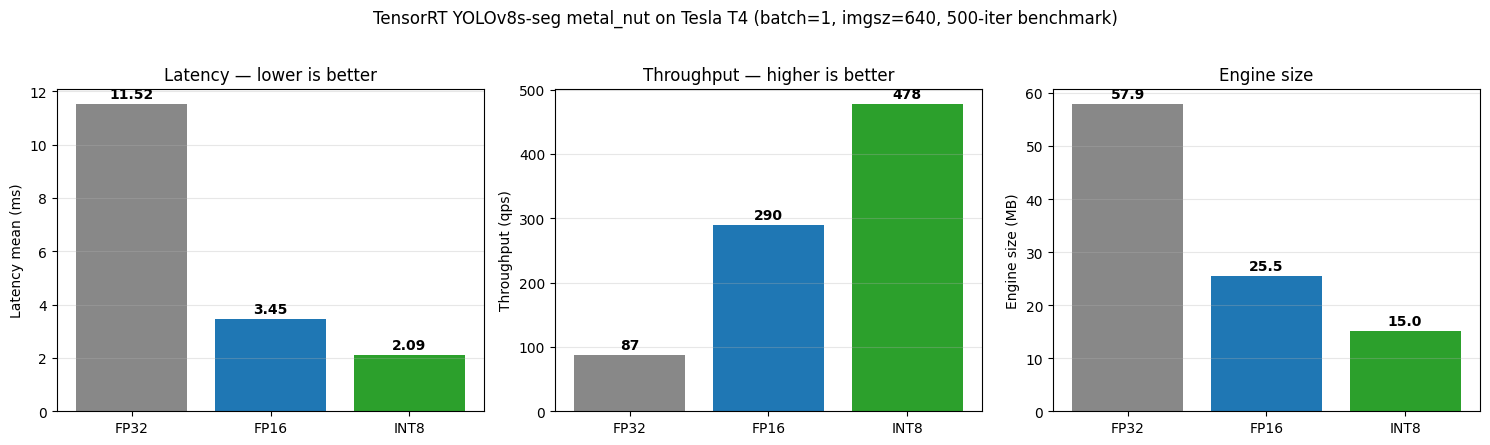

Saved: /kaggle/working/trt_benchmark_t4.png


In [55]:
import matplotlib.pyplot as plt

precisions = ["FP32", "FP16", "INT8"]
latencies = [fp32_stats['mean_ms'], fp16_stats['mean_ms'], int8_stats['mean_ms']]
throughputs = [fp32_stats['throughput_qps'], fp16_stats['throughput_qps'],
               int8_stats['throughput_qps']]
sizes = [
    os.path.getsize(ENGINE_FP32) / 1e6,
    os.path.getsize(ENGINE_FP16) / 1e6,
    os.path.getsize(ENGINE_INT8) / 1e6,
]
colors = ["#888", "#1f77b4", "#2ca02c"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

bars = axes[0].bar(precisions, latencies, color=colors)
axes[0].set_ylabel("Latency mean (ms)")
axes[0].set_title("Latency — lower is better")
axes[0].grid(axis="y", alpha=0.3)
for b, v in zip(bars, latencies):
    axes[0].text(b.get_x() + b.get_width()/2, v + max(latencies)*0.02,
                 f"{v:.2f}", ha="center", fontweight="bold")

bars = axes[1].bar(precisions, throughputs, color=colors)
axes[1].set_ylabel("Throughput (qps)")
axes[1].set_title("Throughput — higher is better")
axes[1].grid(axis="y", alpha=0.3)
for b, v in zip(bars, throughputs):
    axes[1].text(b.get_x() + b.get_width()/2, v + max(throughputs)*0.02,
                 f"{v:.0f}", ha="center", fontweight="bold")

bars = axes[2].bar(precisions, sizes, color=colors)
axes[2].set_ylabel("Engine size (MB)")
axes[2].set_title("Engine size")
axes[2].grid(axis="y", alpha=0.3)
for b, v in zip(bars, sizes):
    axes[2].text(b.get_x() + b.get_width()/2, v + max(sizes)*0.02,
                 f"{v:.1f}", ha="center", fontweight="bold")

fig.suptitle(
    "TensorRT YOLOv8s-seg metal_nut on Tesla T4 (batch=1, imgsz=640, 500-iter benchmark)",
    fontsize=12,
)
plt.tight_layout(rect=[0, 0, 1, 0.96])

PLOT_PATH = "/kaggle/working/trt_benchmark_t4.png"
plt.savefig(PLOT_PATH, dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved: {PLOT_PATH}")

---
## 12. Limitations & Future Work
#
### Limitations
1. **T4 / TRT 10 specific.** Engine plan files are not portable across GPU
   architectures or TRT major versions. Production deployment to A10/L40S
   requires per-target re-build.
2. **Single-stream batch=1.** DeepStream multi-stream throughput with batched
   inference is the production-relevant metric.
3. **Per-precision mAP not measured.** FP16 numerical drift suggests negligible
   mAP impact; INT8 drift will affect mAP — exact figure pending on-device
   verification.
#
### Next Steps
- Day 5: DeepStream pipeline on NVIDIA LaunchPad (DeepStream 7.x container,
  `nvinfer` plugin consuming the FP16 engine).
- Day 8: ISP-aware augmentation robustness study comparing per-precision
  degradation under sensor noise / exposure drift.
- Production benchmark on Ampere+ (A10 via NVIDIA Brev): expected INT8 speedup
  6-8× per published NVIDIA TRT benchmarks.